<a href="https://colab.research.google.com/github/anindyabera3/graph_analysis/blob/main/Network_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# SAMPLE DATA

df = pd.DataFrame({
    "company": [
        "ABC Pvt Ltd",
        "XYZ Traders",
        "MNO Exports",
        "PQR Industries",
        "LMN Corp"
    ],
    "director": [
        "Rahul Sen",
        "Rahul Sen",
        "Amit Das",
        "Suman Roy",
        "Suman Roy"
    ],
    "address": [
        "12 Park Street",
        "45 Lake Road",
        "12 Park Street",
        "99 Salt Lake",
        "99 Salt Lake"
    ],
    "email": [
        "rahul@gmail.com",
        "rahul@gmail.com",
        "amit@yahoo.com",
        "suman@gmail.com",
        "lmn@gmail.com"
    ]
})

In [3]:
print(df)

          company   director         address            email
0     ABC Pvt Ltd  Rahul Sen  12 Park Street  rahul@gmail.com
1     XYZ Traders  Rahul Sen    45 Lake Road  rahul@gmail.com
2     MNO Exports   Amit Das  12 Park Street   amit@yahoo.com
3  PQR Industries  Suman Roy    99 Salt Lake  suman@gmail.com
4        LMN Corp  Suman Roy    99 Salt Lake    lmn@gmail.com


In [4]:
G = nx.Graph()

for _, row in df.iterrows():

    company = f"COMPANY::{row['company']}"
    director = f"DIRECTOR::{row['director']}"
    address = f"ADDRESS::{row['address']}"
    email = f"EMAIL::{row['email']}"

    # Add nodes
    G.add_node(company, node_type="company")
    G.add_node(director, node_type="director")
    G.add_node(address, node_type="address")
    G.add_node(email, node_type="email")

    # Add edges
    G.add_edge(company, director, relation="HAS_DIRECTOR")
    G.add_edge(company, address, relation="REGISTERED_AT")
    G.add_edge(company, email, relation="USES_EMAIL")


Processing NETWORK_ID_1
--------------------------------------------------


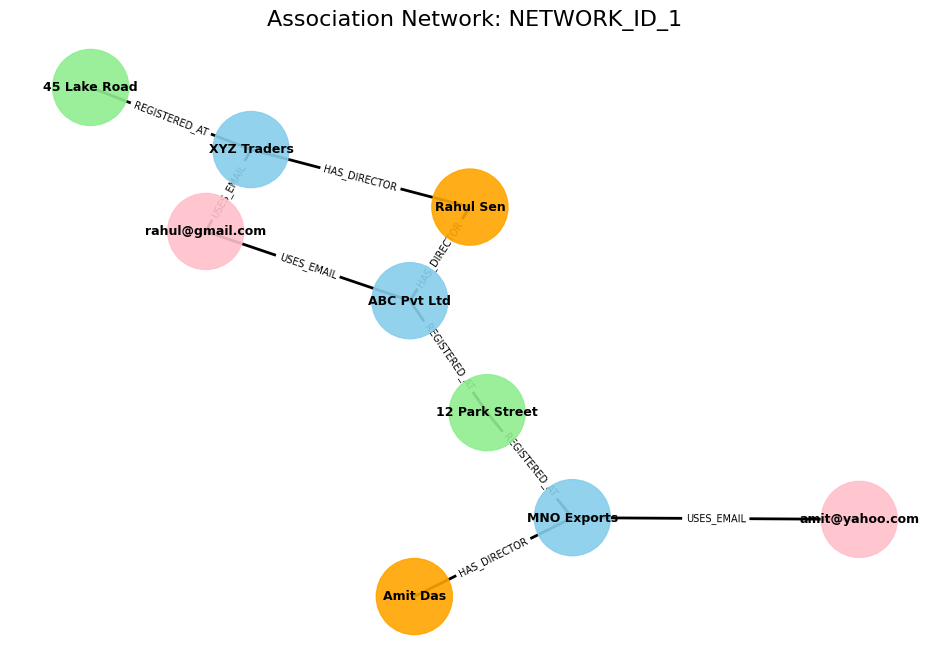


Processing NETWORK_ID_2
--------------------------------------------------


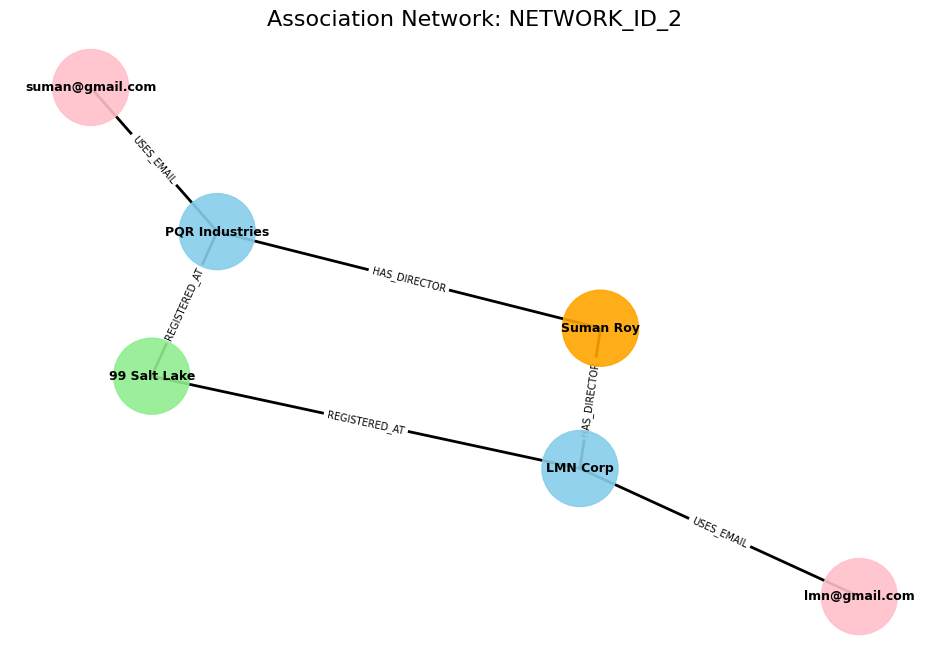


Network data exported to network_mapping.csv


In [15]:
connected_components = list(nx.connected_components(G))
network_records = []
network_counter = 1

for comp in connected_components:
    subgraph = G.subgraph(comp)

    # Identify companies in network
    companies = [node.split("::")[1] for node in comp if node.startswith("COMPANY::")]

    # Keep only networks having >= 1 company
    if len(companies) >= 1:
        network_id = f"NETWORK_ID_{network_counter}"
        print(f"\nProcessing {network_id}")
        print("-" * 50)

        # Add to records
        for node in comp:
            node_type, value = node.split("::", 1)
            network_records.append({
                "network_id": network_id,
                "node_type": node_type,
                "value": value
            })

        # --- VISUALIZATION ---
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(subgraph, seed=42, k=0.6)

        # Color mapping based on node type
        color_map = []
        for node, attr in subgraph.nodes(data=True):
            ntype = attr.get("node_type")
            if ntype == "company": color_map.append("skyblue")
            elif ntype == "director": color_map.append("orange")
            elif ntype == "address": color_map.append("lightgreen")
            elif ntype == "email": color_map.append("pink")
            else: color_map.append("gray")

        # Labels
        labels = {node: node.split("::")[1] for node in subgraph.nodes()}

        # Draw graph
        nx.draw_networkx_nodes(subgraph, pos, node_color=color_map, node_size=3000, alpha=0.9)
        nx.draw_networkx_edges(subgraph, pos, width=2)
        nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=9, font_weight="bold")

        edge_labels = nx.get_edge_attributes(subgraph, "relation")
        nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=7)

        plt.title(f"Association Network: {network_id}", fontsize=16)
        plt.axis("off")
        plt.savefig(f"{network_id}.png", dpi=300, bbox_inches="tight")
        plt.show()

        network_counter += 1

# Export the resulting mapping
network_df = pd.DataFrame(network_records)
network_df.to_csv("network_mapping.csv", index=False)
print("\nNetwork data exported to network_mapping.csv")

In [16]:


# ---------------------------------------------------
# EXPORT NETWORK DATAFRAME
# ---------------------------------------------------

network_df = pd.DataFrame(network_records)

print("\nNETWORK EXPORT DATAFRAME")
print(network_df)

# Export CSV
network_df.to_csv(
    "network_mapping.csv",
    index=False
)

print("\nCSV exported successfully")


NETWORK EXPORT DATAFRAME
      network_id node_type            value
0   NETWORK_ID_1   ADDRESS     45 Lake Road
1   NETWORK_ID_1     EMAIL   amit@yahoo.com
2   NETWORK_ID_1   COMPANY      XYZ Traders
3   NETWORK_ID_1   COMPANY      MNO Exports
4   NETWORK_ID_1     EMAIL  rahul@gmail.com
5   NETWORK_ID_1  DIRECTOR         Amit Das
6   NETWORK_ID_1  DIRECTOR        Rahul Sen
7   NETWORK_ID_1   ADDRESS   12 Park Street
8   NETWORK_ID_1   COMPANY      ABC Pvt Ltd
9   NETWORK_ID_2     EMAIL  suman@gmail.com
10  NETWORK_ID_2     EMAIL    lmn@gmail.com
11  NETWORK_ID_2   COMPANY   PQR Industries
12  NETWORK_ID_2   ADDRESS     99 Salt Lake
13  NETWORK_ID_2   COMPANY         LMN Corp
14  NETWORK_ID_2  DIRECTOR        Suman Roy

CSV exported successfully
